In [ ]:
# installing required libraries
!pip install pennylane kagglehub torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.9 MB/s eta 0:00:00


In [ ]:
# importing required libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import pennylane as qml
import kagglehub
import numpy as np

In [ ]:
# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# downloading the dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_path = path + "/chest_xray"
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray


In [ ]:
# image preprocessing
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [ ]:
# Loading dataset
train_dataset = torchvision.datasets.ImageFolder(
    dataset_path + "/train",
    transform=transform
)
test_dataset = torchvision.datasets.ImageFolder(
    dataset_path + "/test",
    transform=transform
)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [ ]:
# handling class imbalance
labels = train_dataset.targets
class_counts = np.bincount(labels)
total = sum(class_counts)
weights = torch.tensor(
    [total/class_counts[i] for i in range(len(class_counts))],
    dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
# Pretrained CNN Feature Extractor
resnet = models.resnet18(pretrained=True)
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features,4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Quantum circuit
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [ ]:
# Quantum Layer
weight_shapes = {"weights": (2, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [ ]:
# Hybrid Quantum Model
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = resnet
        self.quantum = qlayer
        self.fc = nn.Linear(4,2)
    def forward(self,x):
        x = self.cnn(x)
        x = self.quantum(x)
        x = self.fc(x)
        return x

In [ ]:
# Initializing Model
model = HybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [31]:
# training the model
epochs = 8
for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

# saving the model
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")

Epoch: 1 Loss: 99.23167550563812
Epoch: 2 Loss: 85.00481685996056
Epoch: 3 Loss: 75.80603659152985
Epoch: 4 Loss: 67.90865367650986
Epoch: 5 Loss: 60.970114946365356
Epoch: 6 Loss: 55.70274838805199
Epoch: 7 Loss: 50.83106845617294
Epoch: 8 Loss: 47.080917209386826
Model saved successfully!


In [32]:
# evaluation
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix

classes = ["Normal", "Pneumonia"]

correct = 0
total = 0
printed = False

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        if not printed:
            for i, prob in enumerate(probs[0]):
                print(f"{classes[i]} Probability: {prob.item()*100:.2f}%")
            confidence, pred_sample = torch.max(probs, 1)
            print("\nFinal Prediction:", classes[pred_sample[0].item()])
            print("Confidence: {:.2f}%".format(confidence[0].item()*100))
            printed = True
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print("\nQuantum Hybrid Accuracy: {:.2f}%".format(accuracy))

Normal Probability: 69.29%
Pneumonia Probability: 30.71%

Final Prediction: Normal
Confidence: 69.29%

Quantum Hybrid Accuracy: 82.21%



Confusion Matrix:
 [[148  86]
 [ 25 365]]


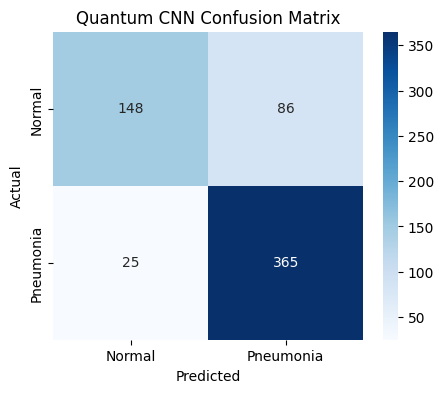


Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.63      0.73       234
   Pneumonia       0.81      0.94      0.87       390

    accuracy                           0.82       624
   macro avg       0.83      0.78      0.80       624
weighted avg       0.83      0.82      0.82       624



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Quantum CNN Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))